In [2]:
import numpy as np
import matplotlib.pyplot as plt

import scipy

In [102]:
def Lorenz(sigma = 10, b = 8/3, r = 1, IC = [3,3,0]):

    # solver params
    endTime = 100
    teval = np.arange(0,endTime,.01)

    def rhs(t,xyz):
        x, y, z = xyz
        dx = -sigma * x + sigma* y
        dy = -x*z + r*x - y
        dz = x*y - b*z
        return [dx, dy, dz]

    return scipy.integrate.solve_ivp(rhs, (0,endTime), IC, t_eval=teval)




In [103]:
results = []

for ic in [[0,1,0], [0,1.0001,0]]:
    results.append(Lorenz(IC = ic))

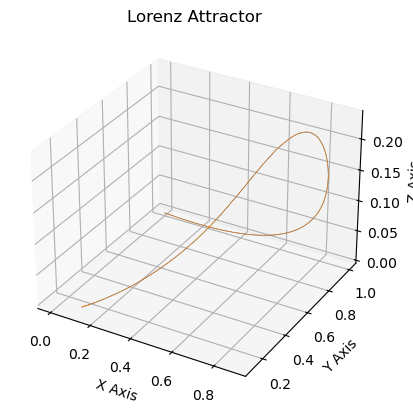

In [104]:
def plotLorenz(results):
    ax = plt.figure().add_subplot(projection='3d')

    for result in results:
        ax.plot(*(result.y), lw=0.5)
    ax.set_xlabel("X Axis")
    ax.set_ylabel("Y Axis")
    ax.set_zlabel("Z Axis")
    ax.set_title("Lorenz Attractor")
    plt.show()
plotLorenz(results)

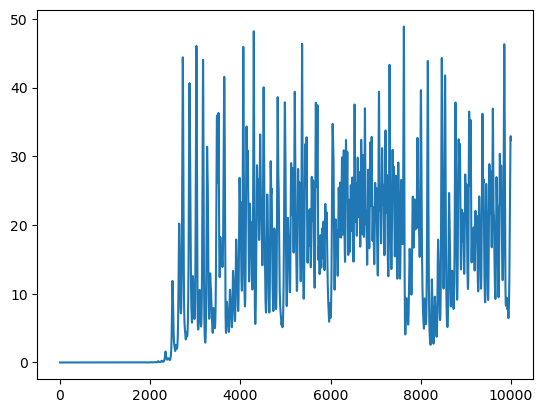

In [101]:
distance = np.linalg.norm(results[0].y - results[1].y, axis = 0)
# distance = (results[0].y[0] - results[1].y[0])
# distance = (results[0].y[2] - results[1].y[2])

plt.plot(distance)

In [ ]:
'''
 experiement cases:

 r < 1: everything goes to origin (try many IC, they should all converge to origin)
 1<r<24: 
 r = 1?
 r = 28: use small variations on (0,1,0) and show chaotic behavior over long time
 try equillibrium points (+-sqrt(b(r-1)), +-sqrt(b(r-1)), r-1) b>0 r>0
 look at the bifurcation?
'''